In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../artifacts/sentiment_analysis.csv')

In [5]:
data.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


##Data Preprocessing

In [6]:
data.shape

(7920, 3)

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

##Text Preprocessing

In [9]:
import re
import string

Convert uppercase to lowercase

In [10]:
data["tweet"].head(5)

0    #fingerprint #Pregnancy Test https://goo.gl/h1...
1    Finally a transparant silicon case ^^ Thanks t...
2    We love this! Would you go? #talk #makememorie...
3    I'm wired I know I'm George I was made that wa...
4    What amazing service! Apple won't even talk to...
Name: tweet, dtype: object

remove links

In [11]:
data["tweet"]=data['tweet'].apply(lambda x: " ".join(re.sub(r'^https?:\/\/.*[\r\n]*','', x, flags=re.MULTILINE) for x in x.split()))

In [12]:
data["tweet"].head(5)

0    #fingerprint #pregnancy test  #android #apps #...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
Name: tweet, dtype: object

remove punctuatins

In [12]:
def remove_punctuations(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation, '')
        return text

data["tweet"] = data["tweet"].apply(remove_punctuations)        

In [13]:
data["tweet"].head(5)

0    #fingerprint #Pregnancy Test  #android #apps #...
1    Finally a transparant silicon case ^^ Thanks t...
2    We love this Would you go? #talk #makememories...
3    I'm wired I know I'm George I was made that wa...
4    What amazing service Apple won't even talk to ...
Name: tweet, dtype: object

remove numbers

In [14]:
data["tweet"] = data['tweet'].str.replace(r'\d+', '', regex=True)

In [15]:
data["tweet"].tail(10)

7910    Perfect match #instagood #applewatch #red #ins...
7911    I am completely in love with the new iPhone em...
7912    Tune in. Turn on. Drop out. & #GTD in one app ...
7913    Ok so my galaxy crashed after one day now I ha...
7914    Gain Followers RT This MUST FOLLOW ME I FOLLOW...
7915    Live out loud #lol #liveoutloud #selfie #smile...
7916    We would like to wish you an amazing day Make ...
7917    Helping my lovely  year old neighbor with her ...
7918    Finally got my #smart #pocket #wifi stay conne...
7919    Apple Barcelona #Apple #Store #BCN #Barcelona ...
Name: tweet, dtype: object

remove stop words

In [20]:
!pip install nltk

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.5 MB 1.4 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.5 MB 1.4 MB/s eta 0:00:01
   ---------------------------------- ----- 1.3/1.5 MB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.5 MB/s  0:00:01

   ---------------------------------------- 0/3 [regex]
   ---------------------------------------- 0/3 [regex]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- --------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import nltk

In [22]:
nltk.download('stopwords', download_dir='../static/model')

[nltk_data] Downloading package stopwords to ../static/model...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [16]:
with open('../static/model/corpora/stopwords/english','r') as file:
    sw = file.read().splitlines()

In [17]:
sw

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [18]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(w for w in x.split() if w not in sw))

stemming

In [19]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

ModuleNotFoundError: No module named 'nltk'

In [ ]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(ps.stem(x) for x in x.split()))

In [ ]:
data["tweet"].head()

In [ ]:
data

In [20]:
import re

data["tweet"] = data["tweet"].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x))


In [22]:
data

,id,label,tweet
0,1,0,fingerprint Pregnancy Test android apps beauti...
1,2,0,Finally transparant silicon case Thanks uncle...
2,3,0,We love Would go talk makememories unplug rela...
3,4,0,Im wired I know Im George I made way iphone c...
4,5,1,What amazing service Apple even talk question ...
...,...,...,...
7915,7916,0,Live loud lol liveoutloud selfie smile sony mu...
7916,7917,0,We would like wish amazing day Make every minu...
7917,7918,0,Helping lovely year old neighbor iPad morning ...
7918,7919,0,Finally got smart pocket wifi stay connected a...


In [23]:
data["tweet"].head(5)

0    fingerprint Pregnancy Test android apps beauti...
1    Finally transparant silicon case  Thanks uncle...
2    We love Would go talk makememories unplug rela...
3    Im wired I know Im George I made way  iphone c...
4    What amazing service Apple even talk question ...
Name: tweet, dtype: object

Building Vacabulary

In [28]:
from collections import Counter
vocab = Counter()

In [29]:
vocab

Counter()

In [30]:
for sentence in data['tweet']:
    vocab.update(sentence.split())

In [31]:
vocab

Counter({'iphone': 2591,
         'apple': 1791,
         'I': 1771,
         'iPhone': 1218,
         'Apple': 1006,
         'samsung': 928,
         'phone': 884,
         'new': 860,
         'sony': 550,
         'Samsung': 466,
         'life': 392,
         'My': 389,
         'like': 379,
         'RT': 355,
         'me': 341,
         'FOLLOW': 312,
         'cute': 310,
         'day': 307,
         'ipad': 294,
         'Gain': 294,
         'photography': 285,
         'instagram': 280,
         'android': 279,
         'love': 279,
         'today': 278,
         'Sony': 270,
         'Im': 268,
         'The': 266,
         'fun': 263,
         'New': 259,
         'Follow': 255,
         'get': 249,
         'instagood': 247,
         'This': 229,
         'music': 225,
         'news': 224,
         'beautiful': 222,
         'got': 216,
         'funny': 215,
         'fashion': 214,
         'case': 213,
         'lol': 194,
         'tech': 194,
         'galaxy': 1

In [32]:
tokens = [key for key in vocab if vocab[key] > 10]

In [33]:
tokens

['android',
 'apps',
 'beautiful',
 'cute',
 'health',
 'igers',
 'iphoneonly',
 'iphonesia',
 'iphone',
 'Finally',
 'case',
 'Thanks',
 'yay',
 'Sony',
 'Xperia',
 'S',
 'We',
 'love',
 'go',
 'talk',
 'relax',
 'smartphone',
 'wifi',
 'connect',
 'Im',
 'I',
 'know',
 'made',
 'way',
 'home',
 'What',
 'amazing',
 'service',
 'Apple',
 'even',
 'pay',
 'stupid',
 'support',
 'iPhone',
 'software',
 'update',
 'fucked',
 'phone',
 'big',
 'time',
 'Stupid',
 'iPhones',
 'Happy',
 'us',
 'instapic',
 'instadaily',
 'sony',
 'xperia',
 'New',
 'C',
 'charger',
 'cable',
 'Amazon',
 'Year',
 'technology',
 'iPhoneX',
 'shopping',
 'music',
 'likeforlike',
 'Photo',
 'fun',
 'selfie',
 'water',
 'camera',
 'picoftheday',
 'sun',
 'instagood',
 'boy',
 'apple',
 'make',
 'new',
 'ipod',
 'dont',
 'color',
 'every',
 'Not',
 'need',
 'to',
 'really',
 'dropped',
 'design',
 'giving',
 'another',
 'crazy',
 'lol',
 'Work',
 'hard',
 'Hard',
 'Lol',
 'iPad',
 'Shopping',
 'battery',
 'charge

In [34]:
def save_vocabulary(lines, filename):
    data = '\n'.join(lines)
    file = open(filename, 'w', encoding="utf-8")
    file.write(data)
    file.close()

save_vocabulary(tokens, '../static/model/vocabulary.txt')    

##Divide DataSet

In [42]:
x = data['tweet']
y = data['label']

In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2)

In [ ]:
X_train.shape

In [ ]:
X_test.shape

In [ ]:
import numpy as np

def vectorizer(ds, vocabulary):
    vectorized_lst = []

    for sentence in ds:
        sentence_vec = np.zeros(len(vocabulary))

        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_vec[i] = 1

        vectorized_lst.append(sentence_vec)

    return np.asarray(vectorized_lst, dtype=np.float32)


In [ ]:
vectorized_x_train = vectorizer(X_train, tokens)

In [ ]:
vectorized_x_train

In [ ]:
vectorized_x_test = vectorizer(X_test, tokens)

In [ ]:
vectorized_x_train

In [ ]:
y_train

In [ ]:
y_train.value_counts()

##Handle imbalance dataset

In [ ]:
!pip install imbalanced-learn

In [61]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
vectorized_x_train_smote, y_train_smote = smote.fit_resample(vectorized_x_train, y_train)
print(vectorized_x_train_smote.shape, y_train_smote.shape)

(9440, 1308) (9440,)


In [62]:
y_train_smote.value_counts()

label
1    4720
0    4720
Name: count, dtype: int64

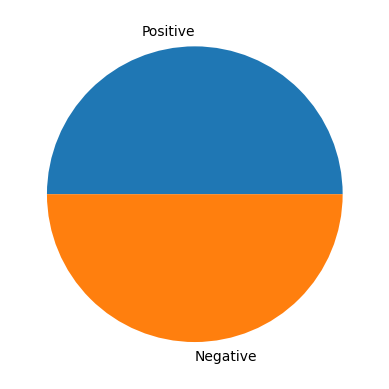

In [63]:
plt.pie(np.array([y_train_smote.value_counts()[0], y_train_smote.value_counts()[1]]), labels=['Positive', 'Negative'])
plt.show()

In [64]:
vectorized_x_train_smote

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(9440, 1308), dtype=float32)

In [65]:
y_train_smote

0       1
1       1
2       0
3       0
4       1
       ..
9435    1
9436    1
9437    1
9438    1
9439    1
Name: label, Length: 9440, dtype: int64

In [66]:
vectorized_x_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1584, 1308), dtype=float32)

In [67]:
y_test

2054    0
3649    0
6153    0
2072    0
4538    1
       ..
5959    0
3284    1
661     0
3454    1
4716    0
Name: label, Length: 1584, dtype: int64

### model train and evaluation

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [58]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def training_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred), 3)
    rec = round(recall_score(y_act, y_pred), 3)
    f1 = round(f1_score(y_act, y_pred), 3)
    print(f'Training Scores:\n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')
    
def validation_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred), 3)
    rec = round(recall_score(y_act, y_pred), 3)
    f1 = round(f1_score(y_act, y_pred), 3)
    print(f'Testing Scores:\n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')

###Logistic Regration 

In [68]:
lr = LogisticRegression()
lr.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = lr.predict(vectorized_x_train_smote)

y_test_pred = lr.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy = 0.933
	Precision = 0.906
	Recall = 0.965
	F1-Score = 0.935
Testing Scores:
	Accuracy = 0.871
	Precision = 0.7
	Recall = 0.88
	F1-Score = 0.78


In [69]:
mnb = MultinomialNB()
mnb.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = mnb.predict(vectorized_x_train_smote)

y_test_pred = mnb.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy = 0.901
	Precision = 0.858
	Recall = 0.961
	F1-Score = 0.906
Testing Scores:
	Accuracy = 0.855
	Precision = 0.654
	Recall = 0.937
	F1-Score = 0.77


In [70]:
dt = DecisionTreeClassifier()

dt.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = dt.predict(vectorized_x_train_smote)

y_test_pred = dt.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0
Testing Scores:
	Accuracy = 0.789
	Precision = 0.592
	Recall = 0.598
	F1-Score = 0.595


In [71]:
rf = RandomForestClassifier()

rf.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = rf.predict(vectorized_x_train_smote)

y_test_pred = rf.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0
Testing Scores:
	Accuracy = 0.854
	Precision = 0.722
	Recall = 0.71
	F1-Score = 0.716


In [72]:
svm = SVC()

svm.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = svm.predict(vectorized_x_train_smote)

y_test_pred = svm.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy = 0.973
	Precision = 0.957
	Recall = 0.991
	F1-Score = 0.974
Testing Scores:
	Accuracy = 0.881
	Precision = 0.745
	Recall = 0.82
	F1-Score = 0.78


In [73]:
import pickle
with open('../static/model/model.pickle','wb') as file:
  pickle.dump(lr,file)